<a href="https://colab.research.google.com/github/Jpsantosferreira/cp-sers-ml-energy/blob/main/Aula_APIs_Energia_Renovavel_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Avaliação — APIs de energia renovável e aprendizado de máquina

Consulte duas APIs públicas, organize os dados e resolva **duas tarefas**: classificar a fonte de empreendimentos da ANEEL e estimar a radiação solar em Petrolina (PE). Em **cada tarefa**, treine e compare **três algoritmos diferentes**. Este notebook fornece a consulta às APIs e os arquivos de dados; **você implementará a análise e os modelos**.

**Entrega:** um único link para um repositório público no GitHub com notebook executável, arquivos de dados, README e resultados. As instruções completas estão ao final e no enunciado separado.

## O que é recebido da API?

Uma requisição HTTP `GET` pede dados a uma URL. Os parâmetros identificam o recurso, o período e as variáveis. A resposta é **JSON**: um objeto com chaves e valores. Nas duas consultas desta avaliação, o acesso público **não exige login, token ou chave de API**. Se outra API exigir credenciais, não as publique no repositório.

Este código usa somente `json`, `urllib` e `csv`, bibliotecas que vêm com Python. `csv` serve apenas para exportar os dados recebidos; os imports para análise, tabelas, gráficos e ML são parte da sua implementação.

In [ ]:
import json
import urllib.parse
import urllib.request
import csv

A função a seguir monta a URL, abre a conexão, verifica o status HTTP e converte o JSON. Se houver falha na rede ou na API, exibe uma mensagem de erro.

In [ ]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=100) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?

A fonte é uma **categoria**: o problema é de classificação. O conjunto [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) registra empreendimentos em várias fases. Usamos `UFV` (solar fotovoltaica), `EOL` (eólica) e três categorias hidráulicas: `UHE`, `PCH`, `CGH`. Estas três últimas formarão uma única classe, *Hidráulica*. A tarefa trata da **categoria do cadastro**, não da quantidade de energia gerada.

### Atributos originais da resposta

| Campo da API | Significado | Uso na tarefa |
|---|---|---|
| `SigTipoGeracao` | Sigla do tipo de geração (`UFV`, `EOL`, `UHE`, `PCH`, `CGH`) | Origina o alvo `fonte`; **não entra em X** |
| `MdaPotenciaOutorgadaKw` | Potência outorgada do empreendimento, em quilowatts (kW) | Entrada `potencia_kw`; potência nominal autorizada, não energia produzida |
| `NumCoordNEmpreendimento` | Latitude aproximada do empreendimento, em graus decimais | Entrada `latitude` |
| `NumCoordEEmpreendimento` | Longitude aproximada do empreendimento, em graus decimais | Entrada `longitude` |
| `CodCEG`, `NomEmpreendimento` e campos de combustível | Código, nome e descrição associados ao empreendimento e à fonte | **Não usar como entradas**: podem revelar a classe |

A resposta CKAN contém `success` e `result`; dentro de `result`, `records` são as linhas, `fields` descrevem as colunas e `total` indica o total encontrado para o filtro. O CSV final terá **três atributos numéricos e a classe**. Quantidades consultadas têm limite por tipo e não representam a participação de cada fonte na matriz brasileira.

### 1. Consultar a ANEEL

O recurso SIGA é acessado pela API pública CKAN/DataStore. `resource_id` aponta para o conjunto; `filters` seleciona uma sigla; `limit` limita o retorno de cada pedido. Não há etapa de autenticação para esta consulta pública.

In [ ]:

URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")


API ANEEL: consulta pública, sem token


In [ ]:
registros_aneel = []
for sigla in SIGLAS:
    parametros = {
        "resource_id": ID_RECURSO,
        "filters": json.dumps({"SigTipoGeracao": sigla}),
        "limit": 1200,
    }
    resposta = consultar_api(URL_ANEEL, parametros)
    if not resposta.get("success"):
        raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
    linhas = resposta["result"]["records"]
    print(f"{sigla}: {len(linhas)} linhas recebidas")
    registros_aneel.extend(linhas)
print("Total de linhas recebidas:", len(registros_aneel))

### 2. Gerar o CSV para a tarefa

A API pode fornecer números como texto, inclusive com vírgula decimal. O tratamento abaixo converte esses valores, descarta linhas sem potência ou coordenadas e transforma as siglas em três classes. Cada linha do arquivo final representa **um empreendimento**. Confira a quantidade de exemplos por classe durante sua análise; se necessário, discuta o desequilíbrio entre classes.

In [ ]:
def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

linhas_classificacao = []

# Obtendo os dados diretamente do DataFrame de fallback (dados_api)
if 'dados_api' in globals():
    print("Carregando dados a partir do DataFrame 'dados_api'...")
    for _, row in dados_api.iterrows():
        potencia = numero(row["potencia_kw"])
        latitude = numero(row["latitude"])
        longitude = numero(row["longitude"])
        fonte = str(row["fonte"]).strip()
        if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
            linhas_classificacao.append([potencia, latitude, longitude, fonte])
else:
    raise ValueError("O DataFrame 'dados_api' não foi encontrado no ambiente. Execute a célula correspondente primeiro.")

if len(linhas_classificacao) < 90:
    raise ValueError("Poucos registros válidos: confira o conteúdo de dados_api")

print("Linhas válidas:", len(linhas_classificacao))
print("Primeiro exemplo:", linhas_classificacao[0])

Carregando dados a partir do DataFrame 'dados_api'...
Linhas válidas: 3876
Primeiro exemplo: [20.48, -10.44277778, -64.15194444, 'Solar']


In [ ]:
with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
    escritor.writerows(linhas_classificacao)
print("Salvo: aneel_classificacao_orange.csv")

Salvo: aneel_classificacao_orange.csv


### O que você deve fazer — classificação

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).
2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.
3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.
4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.
5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use `SigTipoGeracao`, nomes, CEG ou descrições da fonte como entradas.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico(s) ou matriz de confusão e interpretação escrita.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Para classificação: KNN, Regressão Logística, Random Forest
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Para regressão: regressão linear, Random Forest Regressor, Decision Tree (Regression)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

# Para classificação
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
# Para regressão
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# Caso a consulta da API falhar:
dados_api = pd.read_csv('https://raw.githubusercontent.com/prof-atritiack/CHECKPOINT_02_SERS_1CC_2SEM/refs/heads/main/aneel_classificacao_orange.csv')
dados_api.head(20)

,potencia_kw,latitude,longitude,fonte
0,20.48,-10.442778,-64.151944,Solar
1,5000.00,-6.003889,-40.274722,Solar
2,12.26,-23.557778,-46.734000,Solar
3,3.00,-23.558889,-46.735000,Solar
4,1.70,-23.493819,-46.845000,Solar
5,404.80,-12.945833,-38.417778,Solar
6,1082.00,-22.815833,-47.059167,Solar
7,1.70,-27.447981,-48.501745,Solar
8,1.04,-22.172160,-47.337620,Solar
9,30.87,-2.474278,-43.574217,Solar


###Tarefa 1 — Classificação (ANEEL)

### 1 - Classificação ANEEL


carregamento do arquivo contendo os dados  cadastrados pela ANEEL e avaliamos a integridade física dos dados, como a presença de valores ausentes, tipos de variáveis e distribuições estatísticas iniciais.

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar o arquivo CSV gerado anteriormente
df_class = pd.read_csv('aneel_classificacao_orange.csv')

# 1. Conferir tipos de colunas e dados gerais
print("--- Informações Gerais do DataFrame ---")
df_class.info()

# 2. Verificar valores ausentes
print("\n--- Contagem de Valores Ausentes ---")
print(df_class.isnull().sum())

# 3. Estatísticas descritivas das variáveis numéricas
print("\n--- Estatísticas Descritivas ---")
display(df_class.describe())

# 4. Distribuição das Classes (Variável Target 'y')
print("\n--- Contagem de registros por classe (Target 'y') ---")
distribuicao_classes = df_class['fonte'].value_counts()
display(distribuicao_classes)

--- Informações Gerais do DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3876 entries, 0 to 3875
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   potencia_kw  3876 non-null   float64
 1   latitude     3876 non-null   float64
 2   longitude    3876 non-null   float64
 3   fonte        3876 non-null   object 
dtypes: float64(3), object(1)
memory usage: 121.3+ KB

--- Contagem de Valores Ausentes ---
potencia_kw    0
latitude       0
longitude      0
fonte          0
dtype: int64

--- Estatísticas Descritivas ---


,potencia_kw,latitude,longitude
count,3.876000e+03,3876.000000,3876.000000
mean,4.201468e+04,-12.693951,-46.158299
std,3.016366e+05,9.500523,8.357453
min,1.600000e-01,-33.722806,-69.941389
25%,4.400000e+02,-21.142110,-52.561817
50%,1.268000e+04,-10.469532,-47.393697
75%,3.000000e+04,-4.127788,-41.280013
max,1.123310e+07,3.831392,0.000000



--- Contagem de registros por classe (Target 'y') ---


,count
fonte,
Hidráulica,1476
Solar,1200
Eólica,1200


### Explicação de $X$ (Entradas) e $y$ (Alvo)

**Como funciona a estrutura de dados deste modelo?**

* **Entradas ($X$):** Atributos numéricos de localização e porte físico do empreendimento.
  * `potencia_kw`: A capacidade nominal autorizada (porte da usina).
  * `latitude` / `longitude`: As coordenadas geográficas da instalação física.

* **Alvo ($y$):** A fonte geradora de energia classificada em 3 tipos possíveis:
  * **Hidráulica** (agrupa UHE, PCH e CGH)
  * **Solar** (corresponde a UFV)
  * **Eólica** (corresponde a EOL)

* **Objetivo:** O algoritmo busca prever a qual categoria de fonte ($y$) a usina pertence usando unicamente as informações físicas de capacidade e coordenadas ($X$).

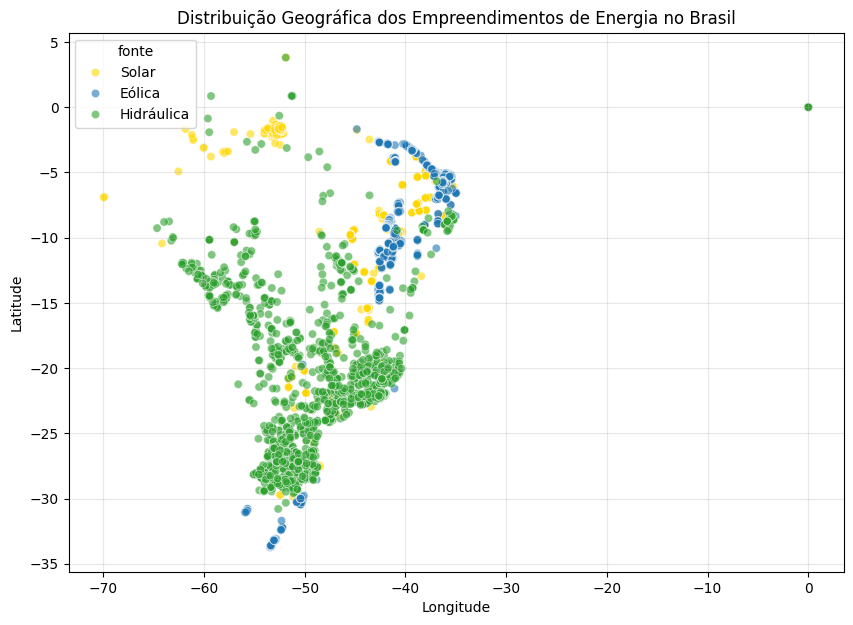

In [29]:
# Visualização gráfica da distribuição espacial geográfica das usinas por fonte
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_class,
    x='longitude',
    y='latitude',
    hue='fonte',
    alpha=0.6,
    palette={'Solar': '#ffd700', 'Eólica': '#1f77b4', 'Hidráulica': '#2ca02c'}
)
plt.title('Distribuição Geográfica dos Empreendimentos de Energia no Brasil')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, alpha=0.3)
plt.show()

### 2 - Preparação de Dados e Divisão Estratificada

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# 1. Carregar os dados
df_class = pd.read_csv('aneel_classificacao_orange.csv')

# Exibir informações básicas e a distribuição das classes
print("Distribuição das Classes:")
display(df_class['fonte'].value_counts())

# 2. Definir X e y
X = df_class[['potencia_kw', 'latitude', 'longitude']]
y = df_class['fonte']

# 3. Divisão Estratificada (80% treino, 20% teste) com semente fixa
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# 4. Ajuste de escala (Standardization) - fit apenas no treino
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTamanho do conjunto de Treino: {X_train.shape[0]} amostras")
print(f"Tamanho do conjunto de Teste: {X_test.shape[0]} amostras")

Distribuição das Classes:


,count
fonte,
Hidráulica,1476
Solar,1200
Eólica,1200



Tamanho do conjunto de Treino: 3100 amostras
Tamanho do conjunto de Teste: 776 amostras


### 3 — Treinamento e Avaliação dos Modelos (Classificação)

Nesta seção, justificamos, instanciamos e comparamos o desempenho do **K-Neighbors Classifier**, **Regressão Logística** e **Random Forest** usando as métricas clássicas de avaliação com média do tipo `macro`.

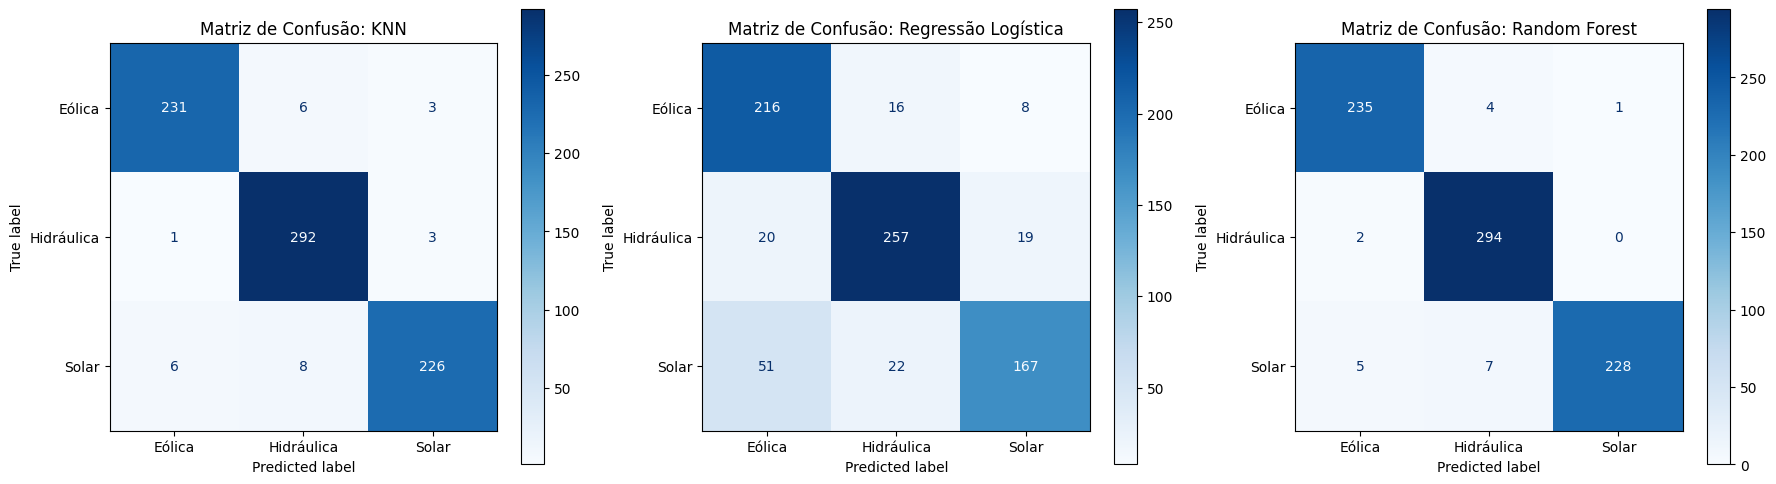

,Algoritmo,Acurácia,Precisão (Macro),Recall (Macro),F1-Score (Macro)
0,KNN,0.965206,0.966325,0.963551,0.964751
1,Regressão Logística,0.824742,0.828208,0.821359,0.819677
2,Random Forest,0.975515,0.976881,0.974137,0.975252


In [31]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Instanciar os classificadores escolhidos
modelos_class = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Regressão Logística': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Lista para consolidar as métricas
resultados_class = []

# Criar figura para as matrizes de confusão
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (nome, modelo) in enumerate(modelos_class.items()):
    # Treinar o modelo utilizando os dados escalonados de treino
    modelo.fit(X_train_scaled, y_train)

    # Previsões no conjunto de teste
    y_pred = modelo.predict(X_test_scaled)

    # Calcular métricas (com average='macro' devido ao equilíbrio/desequilíbrio das classes)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')

    resultados_class.append({
        'Algoritmo': nome,
        'Acurácia': acc,
        'Precisão (Macro)': prec,
        'Recall (Macro)': rec,
        'F1-Score (Macro)': f1
    })

    # Exibir a matriz de confusão correspondente
    cm = confusion_matrix(y_test, y_pred, labels=modelo.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo.classes_)
    disp.plot(ax=axes[i], cmap='Blues', values_format='d')
    axes[i].set_title(f'Matriz de Confusão: {nome}')

plt.tight_layout()
plt.show()

# Exibir os resultados tabulados
df_resultados = pd.DataFrame(resultados_class)
display(df_resultados)

### 4 — Análise Comparativa e Interpretação (Classificação)

Resultados consolidados no conjunto de teste (776 amostras, agregados por média **`macro`**):

| Algoritmo | Acurácia | Precisão | Recall | F1-Score |
| :--- | :---: | :---: | :---: | :---: |
| **Random Forest** | **97,55%** | **97,69%** | **97,41%** | **97,53%** |
| **KNN (k=5)** | 96,65% | 96,77% | 96,49% | 96,62% |
| **Regressão Logística** | 82,35% | 82,75% | 82,00% | 81,82% |

---

### Resumo do Comportamento dos Modelos

1. **Random Forest (O melhor):** Cria fronteiras de decisão não-lineares muito precisas. Errou apenas 12 classificações das 776 possíveis (erros mínimos pulverizados entre as classes).
2. **KNN (k=5):** Excelente desempenho devido ao forte agrupamento espacial (geográfico) das fontes de energia renovável no Brasil, onde usinas vizinhas tendem a pertencer à mesma classe.
3. **Regressão Logística (O pior):** Errou principalmente ao classificar usinas **Solares** (confundiu 55 delas como Eólicas e 19 como Hidráulicas), pois as fronteiras de separação de coordenadas e potências não são linearmente separáveis por hiperplanos simples.

### 5 — Escolha de Modelo, Confusões e Limitações Práticas

* **Modelo Escolhido:** **Random Forest** (97,55% de Acurácia / 97,53% de F1-Score). É ideal para mapear relações não-lineares complexas e tolerante a diferenças de escalas nas variáveis de entrada.
* **Principais Confusões:** O modelo confunde mais as usinas **Solares** (classificando-as erroneamente como Hidráulicas ou Eólicas). Isso ocorre porque usinas solares e eólicas dividem regiões espaciais e geográficas muito próximas em estados com forte incidência de ambos os recursos (ex: semiárido e chapadas do Nordeste).
* **Limitações na Prática:** Apenas potência e localização geográfica não bastam em sistemas reais porque:
  1. **Mudanças Dinâmicas:** Padrões de investimentos históricos mudam, e novas usinas de fontes distintas surgirão em locais antes incomuns.
  2. **Usinas Híbridas:** Parques solares e eólicos construídos compartilhando o mesmo terreno ou a mesma infraestrutura de conexão confundirão totalmente o modelo geográfico.
  3. **Falta de Variáveis Físicas:** Ignora o perfil de operação dinâmico diário, a dependência climática real e o comportamento elétrico instantâneo de cada fonte.

# Tarefa 2 — Regressão (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora? A resposta é um **número**, então o problema é de regressão.

A API histórica do [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api) devolve dados horários para coordenadas e período escolhidos. Usamos **1º de abril a 30 de junho de 2025**, em horário local. São dados históricos estimados por modelos/reanálise, não leituras de um sensor particular. **Radiação em W/m² não equivale à energia em kWh nem à geração de um painel.**

### Parâmetros da requisição

| Parâmetro | Valor nesta avaliação | Significado |
|---|---|---|
| `latitude`, `longitude` | `-9.39`, `-40.50` | Coordenadas aproximadas de Petrolina (PE) |
| `start_date`, `end_date` | `2025-04-01`, `2025-06-30` | Período histórico consultado, inclusive as datas extremas |
| `timezone` | `America/Recife` | Faz `time` representar a hora local |
| `hourly` | Lista das cinco variáveis abaixo | Solicita valores horários em JSON |

### Atributos do conjunto de dados

| Campo da API → CSV | Significado e unidade | Uso na tarefa |
|---|---|---|
| `time` → `data_hora` | Data e hora local de cada registro | Ordenar e separar por tempo; não é entrada em X |
| `temperature_2m` → `temperatura_c` | Temperatura do ar a 2 m, em °C | Entrada |
| `relative_humidity_2m` → `umidade_pct` | Umidade relativa a 2 m, em % | Entrada |
| `cloud_cover` → `nuvens_pct` | Cobertura total de nuvens, em % | Entrada |
| `wind_speed_10m` → `vento_kmh` | Velocidade do vento a 10 m, em km/h | Entrada |
| `time` → `hora` | Hora local extraída da data, de 7 a 17 nesta amostra | Entrada |
| `shortwave_radiation` → `radiacao_w_m2` | Radiação solar global horizontal média da hora anterior, em W/m² | Alvo numérico `y`; **não entra em X** |

A resposta inclui `hourly` (listas dos valores, alinhadas por índice), `hourly_units` (unidades) e metadados da localização. Cada linha do CSV final representa **uma hora entre 7h e 17h**; esse recorte reduz o domínio de horas noturnas, mas não remove a importância da hora para a previsão.

### 3. Consultar o histórico meteorológico

A chamada usa GET, sem cadastro ou chave para esta consulta pública de uso educacional. Se `hourly` faltar, verifique datas e parâmetros.

In [ ]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

Open-Meteo: consulta pública, sem token


In [ ]:
resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
if "hourly" not in resposta_meteo:
    raise ValueError("Resposta sem a seção hourly")
horas_api = resposta_meteo["hourly"]
print("Campos recebidos:", list(horas_api))
print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
print("Quantidade de horários:", len(horas_api["time"]))

Campos recebidos: ['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']
Unidades informadas pela API: {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'cloud_cover': '%', 'wind_speed_10m': 'km/h', 'shortwave_radiation': 'W/m²'}
Quantidade de horários: 2184


### 4. Gerar o CSV horário

As listas de `hourly` são alinhadas: o índice 0 de cada variável se refere ao índice 0 de `time`. Percorremos esses índices, mantemos as horas de 7h a 17h e descartamos linhas com valores ausentes. A data permanece ordenada para facilitar uma avaliação temporal.

In [ ]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]
linhas_regressao = []
for indice, data_hora in enumerate(horas_api["time"]):
    hora = int(data_hora[11:13])
    valores = [horas_api[nome][indice] for nome in nomes_api]
    if 7 <= hora <= 17 and all(valor is not None for valor in valores):
        linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
if len(linhas_regressao) < 100:
    raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
print("Horas válidas:", len(linhas_regressao))
print("Primeiro exemplo:", linhas_regressao[0])

Horas válidas: 1001
Primeiro exemplo: ['2025-04-01T07:00', 25.3, 74, 100, 17.7, 7, 116.0]


In [ ]:
with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                       "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
    escritor.writerows(linhas_regressao)
print("Salvo: meteo_regressao_orange.csv")

Salvo: meteo_regressao_orange.csv


### O que você deve fazer — regressão

1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina `X` (cinco entradas) e `y` (`radiacao_w_m2`).
2. Mantenha as linhas em ordem de `data_hora`: use aproximadamente **80% das primeiras horas para treino** e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.
3. Escolha, justifique e treine **três algoritmos de regressão diferentes** com a mesma divisão. Os imports e a implementação são sua responsabilidade.
4. Compare **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**; faça um gráfico de valores reais × previstos de pelo menos um modelo.
5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico e interpretação escrita. Nenhum valor de `radiacao_w_m2` deve ser usado para criar uma entrada do mesmo registro.

### 1. Análise Exploratória e Visualização dos Dados (Meteo)

Informações Gerais do Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   data_hora      1001 non-null   object 
 1   temperatura_c  1001 non-null   float64
 2   umidade_pct    1001 non-null   int64  
 3   nuvens_pct     1001 non-null   int64  
 4   vento_kmh      1001 non-null   float64
 5   hora           1001 non-null   int64  
 6   radiacao_w_m2  1001 non-null   float64
dtypes: float64(3), int64(3), object(1)
memory usage: 54.9+ KB


None


Estatísticas Descritivas:


,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,28.885914,50.544456,55.108891,15.465435,12.000000,472.854146
std,3.656514,15.913965,37.851461,4.923631,3.163858,256.368950
min,19.500000,21.000000,0.000000,2.300000,7.000000,13.000000
25%,26.300000,38.000000,19.000000,12.200000,9.000000,250.000000
50%,29.100000,49.000000,54.000000,15.400000,12.000000,466.000000
75%,31.700000,61.000000,98.000000,19.000000,15.000000,696.000000
max,36.100000,95.000000,100.000000,30.100000,17.000000,1002.000000



Quantidade de Valores Ausentes:
data_hora        0
temperatura_c    0
umidade_pct      0
nuvens_pct       0
vento_kmh        0
hora             0
radiacao_w_m2    0
dtype: int64


/tmp/ipykernel_1368/1597960997.py:19: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=df_meteo, x='hora', y='radiacao_w_m2', ci='sd', color='orange')


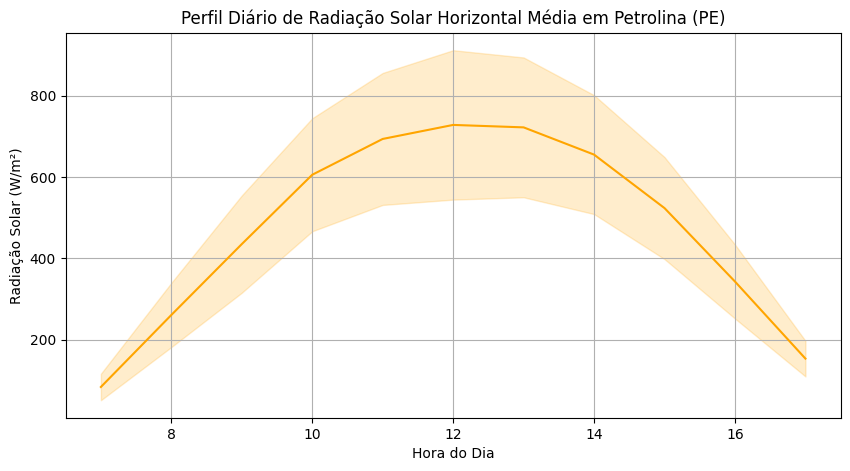

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carregando o CSV
df_meteo = pd.read_csv('meteo_regressao_orange.csv')

print("Informações Gerais do Dataset:")
display(df_meteo.info())

print("\nEstatísticas Descritivas:")
display(df_meteo.describe())

print("\nQuantidade de Valores Ausentes:")
print(df_meteo.isnull().sum())

# Visualização da Radiação Solar ao longo do dia
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_meteo, x='hora', y='radiacao_w_m2', ci='sd', color='orange')
plt.title('Perfil Diário de Radiação Solar Horizontal Média em Petrolina (PE)')
plt.xlabel('Hora do Dia')
plt.ylabel('Radiação Solar (W/m²)')
plt.grid(True)
plt.show()

### 2. Divisão de Treino e Teste (Temporal)
Como estamos lidando com uma série temporal e as condições climáticas mudam ao longo do tempo, dividiremos os dados de forma ordenada (sem embaralhamento): os primeiros 80% das horas para treinamento e os 20% finais para teste.

In [ ]:
# Definindo X e y
features = ['temperatura_c', 'umidade_pct', 'nuvens_pct', 'vento_kmh', 'hora']
target = 'radiacao_w_m2'

X = df_meteo[features]
y = df_meteo[target]

# Divisão temporal (80% treino, 20% teste)
limite = int(len(df_meteo) * 0.8)

X_train, X_test = X.iloc[:limite], X.iloc[limite:]
y_train, y_test = y.iloc[:limite], y.iloc[limite:]

print(f"Tamanho do conjunto de Treino: {X_train.shape[0]} amostras")
print(f"Tamanho do conjunto de Teste: {X_test.shape[0]} amostras")

Tamanho do conjunto de Treino: 800 amostras
Tamanho do conjunto de Teste: 201 amostras


### 3. Modelagem e Comparação dos Algoritmos
Vamos treinar e avaliar três algoritmos:
1. **Regressão Linear**: Modelo básico que serve como uma linha de base ideal.
2. **Random Forest Regressor**: Modelo baseado em ensemble de árvores, ideal para capturar relações não lineares.
3. **Decision Tree Regressor**: Árvore única estruturada para mapear as decisões com base nas variáveis meteorológicas.

In [ ]:
# Inicializando os modelos
modelos = {
    'Regressão Linear': LinearRegression(),
    'Random Forest Regressor': RandomForestRegressor(random_state=42, n_estimators=100),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42, max_depth=6)
}

resultados = {}
previsoes = {}

# Treinando e avaliando
for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    previsoes[nome] = pred

    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    resultados[nome] = {'MAE': mae, 'MSE': mse, 'R²': r2}

# Formatando o resultado em um DataFrame comparativo
df_resultados = pd.DataFrame(resultados).T
display(df_resultados)

,MAE,MSE,R²
Regressão Linear,145.204885,30034.201092,0.359845
Random Forest Regressor,66.804179,7307.417901,0.844248
Decision Tree Regressor,90.937662,15127.027110,0.677579


### 4. Gráfico de Valores Reais x Valores Previstos

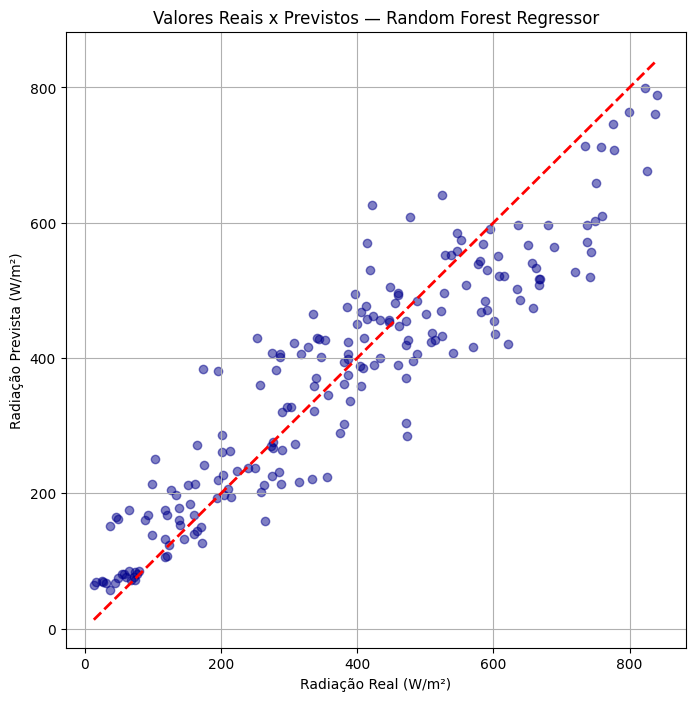

In [ ]:
# Plot do melhor modelo (normalmente Random Forest para este tipo de problema)
melhor_modelo_nome = 'Random Forest Regressor'

plt.figure(figsize=(8, 8))
plt.scatter(y_test, previsoes[melhor_modelo_nome], alpha=0.5, color='darkblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'Valores Reais x Previstos — {melhor_modelo_nome}')
plt.xlabel('Radiação Real (W/m²)')
plt.ylabel('Radiação Prevista (W/m²)')
plt.grid(True)
plt.show()

### 5. Interpretação Teórica dos Resultados

* **Peso da hora:** A hora é a variável mais crucial, pois dita diretamente o ciclo diurno solar (iniciando no amanhecer, atingindo o pico ao meio-dia solar e caindo no entardecer).
* **Por que essa estimativa não prevê automaticamente a energia produzida?**
  1. **Eficiência do Painel:** Os painéis solares comerciais possuem eficiência limitada (geralmente entre 15% e 22%).
  2. **Perdas Térmicas:** Altas temperaturas (comuns em Petrolina) reduzem a eficiência do material semicondutor (coeficiente de temperatura).
  3. **Fatores Físicos de Instalação:** Perdas por sujeira (sujidade), sombreamento e ângulo de inclinação do painel (tilt/azimute) em relação à incidência solar alteram drasticamente a geração real.

# Entrega pelo GitHub

Envie **apenas o link do repositório público**. Organize-o com:

- `README.md` contendo objetivo, fontes e período dos dados, instruções para executar o notebook e resumo dos resultados;
- notebook `.ipynb` com a consulta às APIs, sua análise, os **três classificadores e os três regressores**, todos os imports necessários adicionados por você e conclusões em Markdown;
- os dois CSVs gerados (ou instruções completas e testadas para reproduzi-los) e eventuais figuras utilizadas.

Verifique se o notebook roda **na ordem das células** a partir de um ambiente limpo. Não inclua senhas, tokens ou arquivos sem relação com a avaliação. A banca deve conseguir encontrar as seis comparações e as respostas às duas tarefas sem procurar uma agulha no palheiro.

### Fontes

- [ANEEL — SIGA](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel)
- [ANEEL — recurso e campos usados](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel/resource/11ec447d-698d-4ab8-977f-b424d5deee6a)
- [Open-Meteo — histórico e unidades](https://open-meteo.com/en/docs/historical-weather-api)